In [1]:
import sys
sys.path.append('../src')

# Results of the baseline SmallCNN run (see train.py, models.py).
# Expects a finished run in data/runs/baseline: history.csv + best.pt.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix

from dataset import SpectrogramWindows
from models import SmallCNN

RUN_DIR = Path('../../data/runs/baseline')

history = pd.read_csv(RUN_DIR / 'history.csv')
history

,epoch,train_loss,val_loss,val_acc,val_f1
0,1,1.692184,1.733355,0.462190,0.405097
1,2,1.450284,1.496070,0.526395,0.452314
2,3,1.340902,1.479688,0.537448,0.461163
3,4,1.262486,1.659408,0.479649,0.421084
4,5,1.192747,1.459736,0.565134,0.477238
5,6,1.131449,1.548220,0.514566,0.460544
6,7,1.069629,1.515962,0.549225,0.460145
7,8,1.028241,1.494948,0.544215,0.501735
8,9,0.980141,1.748005,0.443543,0.413644
9,10,0.943393,1.411265,0.563998,0.489391


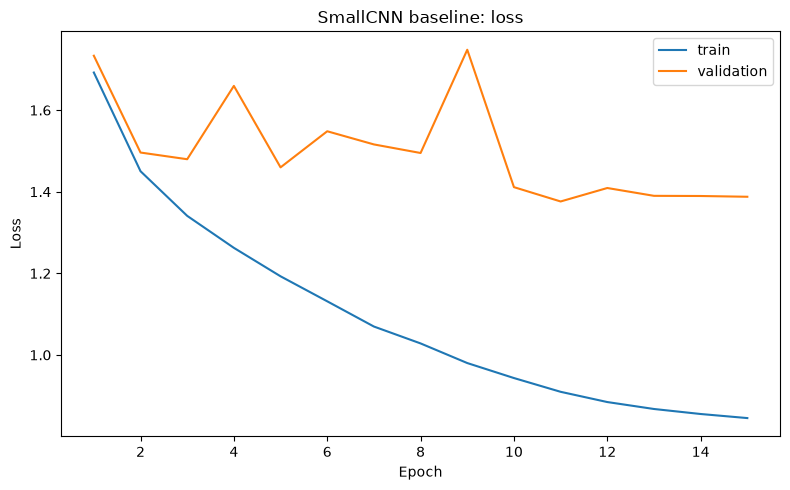

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_loss'], label='train')
plt.plot(history['epoch'], history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SmallCNN baseline: loss')
plt.legend()
plt.tight_layout()
plt.show()

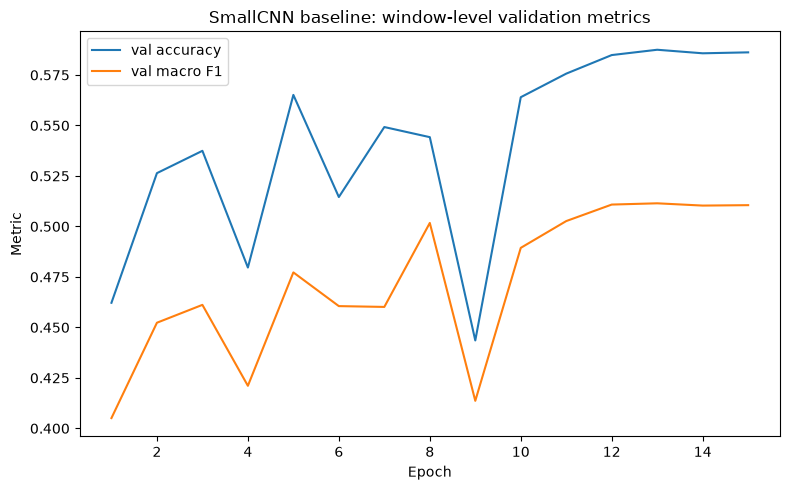

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['val_acc'], label='val accuracy')
plt.plot(history['epoch'], history['val_f1'], label='val macro F1')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('SmallCNN baseline: window-level validation metrics')
plt.legend()
plt.tight_layout()
plt.show()

Train loss падає монотонно, валідаційний гойдається і стабілізується в кінці, коли cosine-розклад знижує lr майже до нуля. Розрив train/val (0.85 проти 1.39) - помірний overfitting: dropout і weight decay його стримують, але за 15 епох модель частково запам'ятовує train. Best-чекпоінт обирається по val macro-F1 - це епоха 13.

In [4]:
# Load the best checkpoint and run inference over all validation windows
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
ckpt = torch.load(RUN_DIR / 'best.pt', map_location=device, weights_only=False)
print(f"best checkpoint: epoch {ckpt['epoch']}, window val_f1={ckpt['val_f1']:.4f}")

val = SpectrogramWindows('../../data/spectrograms', 'validation', normalize=ckpt['normalize'])
model = SmallCNN(len(val.classes)).to(device)
model.load_state_dict(ckpt['model'])
model.eval()

probs = []
with torch.no_grad():
    for x, _ in DataLoader(val, batch_size=256):
        probs.append(torch.softmax(model(x.to(device)), dim=1).cpu())
probs = torch.cat(probs).numpy()

win_true = val.window_labels()
win_pred = probs.argmax(axis=1)
print(f'window-level: acc={(win_pred == win_true).mean():.4f} '
      f'macro_f1={f1_score(win_true, win_pred, average="macro"):.4f} '
      f'({len(val)} windows)')

# track-level: average window probabilities per track, then argmax
track_pos = np.array([pos for pos, _ in val.items])
track_probs = np.stack([probs[track_pos == p].mean(axis=0)
                        for p in range(len(val.track_ids))])
track_true = val.track_labels
track_pred = track_probs.argmax(axis=1)
print(f'track-level:  acc={(track_pred == track_true).mean():.4f} '
      f'macro_f1={f1_score(track_true, track_pred, average="macro"):.4f} '
      f'({len(val.track_ids)} tracks)')

best checkpoint: epoch 13, window val_f1=0.5115


window-level: acc=0.5875 macro_f1=0.5115 (19360 windows)
track-level:  acc=0.6233 macro_f1=0.5557 (1760 tracks)


Track-level метрики очікувано вищі за window-level: accuracy 62.3% проти 58.8%, macro-F1 0.556 проти 0.512. Усереднення ймовірностей 11 вікон гасить випадкові промахи на окремих шматках треку. Фінальна апка працює саме в track-level режимі (накопичене середнє по сесії), тож основна цифра - track-level. Для масштабу: випадкове вгадування на 14 класах дає 7%.

In [5]:
# Per-class recall on tracks, sorted
recalls = {val.classes[c]: (track_pred[track_true == c] == c).mean()
           for c in range(len(val.classes))}
counts = {val.classes[c]: int((track_true == c).sum()) for c in range(len(val.classes))}
per_class = (pd.DataFrame({'recall': recalls, 'n_tracks': counts})
             .sort_values('recall', ascending=False).round(2))
per_class

,recall,n_tracks
Classical,0.90,62
Spoken,0.83,12
Folk,0.78,152
Hip-Hop,0.77,220
Rock,0.77,308
Old-Time / Historic,0.76,51
International,0.74,102
Electronic,0.63,300
Experimental,0.53,225
Country,0.44,18


Найкраще розпізнаються класи з виразним однорідним звучанням: Classical 0.90, Spoken 0.83 - експеримент із мовою як окремим класом удався, попри 118 треків. Провали теж пояснювані: Pop 0.11 - жанр без власного акустичного обличчя, розтягується між Rock/Electronic/Folk; Soul-RnB 0.22 - малий клас, плутається з Hip-Hop і Pop; Instrumental 0.34 - це "жанр за відсутністю вокалу", а не за звучанням, тож тембрально він може бути чим завгодно.

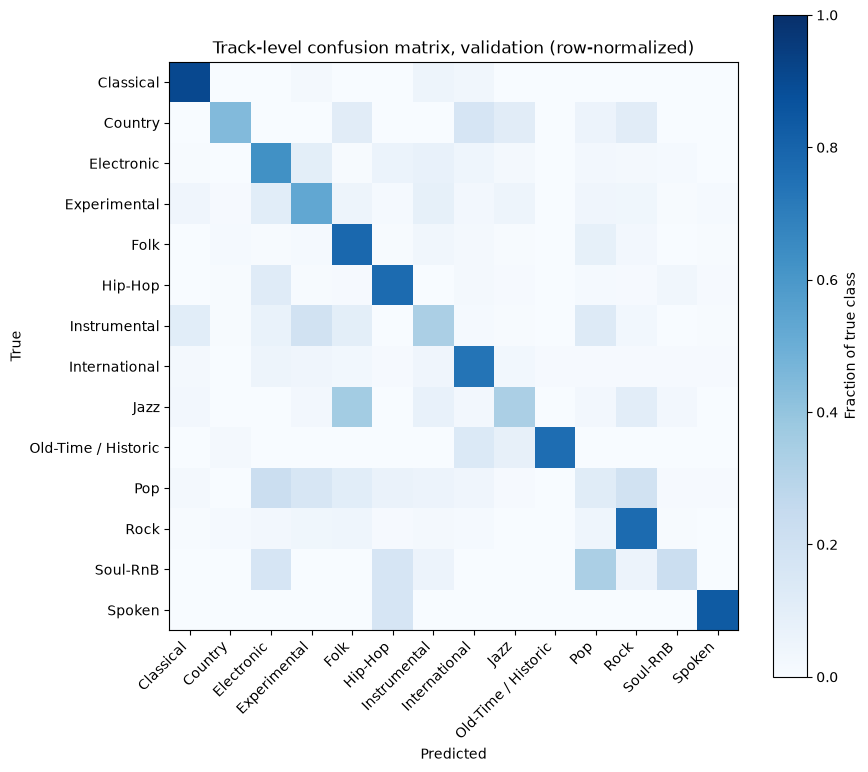

In [6]:
cm = confusion_matrix(track_true, track_pred, normalize='true')

plt.figure(figsize=(9, 8))
plt.imshow(cm, vmin=0, vmax=1, cmap='Blues')
plt.colorbar(label='Fraction of true class')
plt.xticks(range(len(val.classes)), val.classes, rotation=45, ha='right')
plt.yticks(range(len(val.classes)), val.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Track-level confusion matrix, validation (row-normalized)')
plt.tight_layout()
plt.show()

Помилки не хаотичні, а семантичні: Pop розпливається по сусідніх популярних жанрах, Jazz частково йде у Folk, Soul-RnB - у Hip-Hop/Pop, Experimental - в Electronic. Звичайно можна скзати що є деякі проблеми з класами, але в цих класів наприклда є залежності які можуть робити так що і людина буде думати що це той або інакший жанр. Підсумкова планка baseline для transfer learning: track-level accuracy 0.62, macro-F1 0.56 на валідації.